In [1]:
try:
    from drought_ensemble.analysis.paper_figures import utils
    from drought_ensemble.classes import Domain
except ImportError:
    import sys
    from pathlib import Path

    def _find_project_root() -> Path:
        for candidate in [Path.cwd(), *Path.cwd().resolve().parents]:
            if (candidate / "classes" / "Domain.py").is_file():
                return candidate
            nested = candidate / "drought-ensemble"
            if (nested / "classes" / "Domain.py").is_file():
                return nested
        raise ImportError(
            "Install the project with `pip install -e .` from drought-ensemble/, "
            "or run this notebook from inside the project tree."
        )

    _root = _find_project_root()
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))

    from analysis.paper_figures import utils
    from classes import Domain

In [2]:
domain_name = "potomac_without_flow_barrier"
ensemble_name = "ensemble_1"
ensemble_member = "3_year_drought"
PLOTTING_INTERVAL = 219

In [3]:
domain = Domain(domain_name, full_config_file_path_given=False)

In [4]:
data = utils.read_simulation_data(ensemble_name, ensemble_member, domain_name)
data.info()

/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/bwest/conda-envs/droughts/share/proj failed
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: 

xarray.Dataset {
dimensions:
	time = 157680 ;
	z = 10 ;
	y = 136 ;
	x = 70 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

In [5]:
ensemble_member = "baseline"
baseline_data = utils.read_simulation_data(ensemble_name, ensemble_member, domain_name)

/glade/derecho/scratch/bwest/drought-ensemble/analysis/paper_figures/utils.py:35: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  data = xr.open_mfdataset(files, concat_dim="time", combine="nested")


In [ ]:
start_time = 8760*11

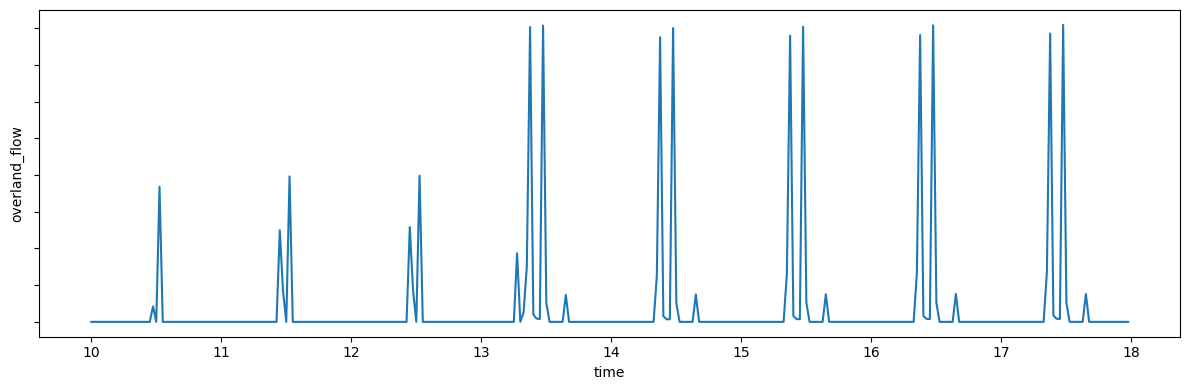

In [7]:
import matplotlib.pyplot as plt

flow = data.overland_flow.isel(
    x=domain.outlet_x,
    y=domain.outlet_y,
    time=slice(start_time, None, PLOTTING_INTERVAL),
)
fig, ax = plt.subplots(figsize=(12, 4))  # stretch horizontally
flow.where(flow > 0, 1e-12).plot(ax=ax)
ax.set_yticklabels([])  # Remove y axis numbers
plt.tight_layout()


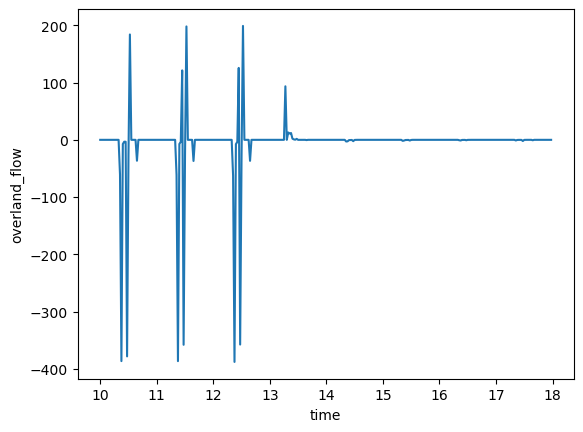

In [8]:
baseline_flow = baseline_data.overland_flow.isel(
    x=domain.outlet_x,
    y=domain.outlet_y,
    time=slice(start_time, None, PLOTTING_INTERVAL),
)
# baseline_flow.where(baseline_flow > 0, 1e-12).plot(yscale="log")
flow_reduction = flow - baseline_flow
flow_reduction.plot()


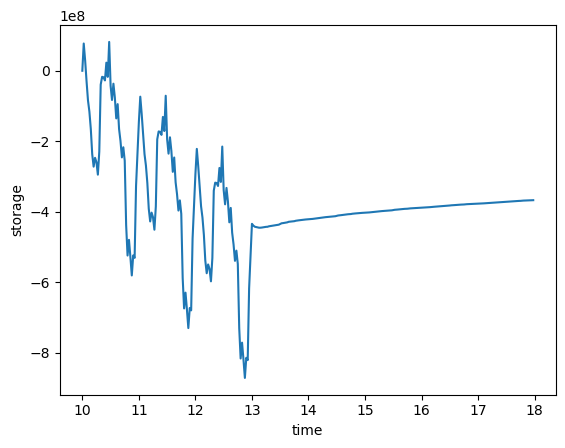

In [9]:
storage = data.storage.isel(

    time=slice(start_time, None, PLOTTING_INTERVAL),
).sum(dim=["x", "y", "z"])
# storage.plot()
baseline_storage = baseline_data.storage.isel(

    time=slice(start_time, None, PLOTTING_INTERVAL),
).sum(dim=["x", "y", "z"])
storage_reduction = storage - baseline_storage
storage_reduction.plot()


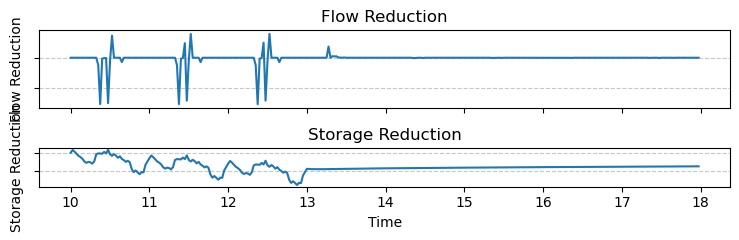

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(7.5, 2.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# Plot Flow Reduction (top panel)
flow_reduction.plot(ax=axes[0], color="C0")
axes[0].set_title('Flow Reduction')
axes[0].set_ylabel('Flow Reduction')
axes[0].grid(True, axis="y", linestyle='--', alpha=0.7)
axes[0].set_yticklabels([])  # Remove y axis numbers
axes[0].label_outer()

# Plot Storage Reduction (bottom panel)
storage_reduction.plot(ax=axes[1], color="C0")
axes[1].set_title('Storage Reduction')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Storage Reduction')
axes[1].grid(True, axis="y", linestyle='--', alpha=0.7)
axes[1].set_yticklabels([])  # Remove y axis numbers
axes[1].label_outer()

plt.tight_layout()
plt.show()